In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os
from google.colab import files

In [ ]:
# Load the image
image = '/lena - ' # Prefix name for saving the images
original_image = scipy.io.loadmat(work_path + '/Data/lena.mat')
original_image = original_image['lena']
M, N = original_image.shape

# Normalize to zero mean and unit varaince
original_image_mean = original_image.mean()
original_image_std = original_image.std()
original_image = (original_image - original_image_mean) / original_image_std

In [ ]:
# Define the coefficients of the 1st order 2-D AR model
# (scan from top-to-bottom and left-to-right)
a10 = 0.7822;
a_11 = 0.0959;
a01 = 0.4464;
a11 = -0.3243;

In [ ]:
# The best linear prediction of the original image x(m,n)
# [x^(m,n) = a10*x(m-1,n) + a_11*x(m+1,n-1) + a01*x(m,n-1) + a11*x(m-1,n-1)]
predicted_image = np.zeros([M,N])

for m in range(1, M-1):
  for n in range(1, N):
    predicted_image[m,n] = a10*original_image[m-1,n] + a_11*original_image[m+1,n-1] + a01*original_image[m,n-1] + a11*original_image[m-1,n-1]

error_image = original_image[1:M-1,1:N] - predicted_image[1:M-1,1:N]

In [ ]:
# Uniformly Quantize the error image
B = 6; # # of bits for quantization

quantization_level = 2 ** B;
quantization_step = (error_image.max() - error_image.min()) / (quantization_level - 1)
error_image_quantized = np.round(error_image/quantization_step)
error_image_quantized = error_image_quantized * quantization_step

quantization_error_DPCM = error_image - error_image_quantized # q(m,n) = e(m,n) - e_0(m,n)

In [ ]:
# Reconstruct the original image x(m,n) (Assume Huffman encoding for transmitting)
# [x^(m,n) = a10*x(m-1,n) + a_11*x(m+1,n-1) + a01*x(m,n-1) + a11*x(m-1,n-1)]
initial_condition = original_image.copy()
initial_condition[1:M-1,1:N] = error_image_quantized
reconstructed_image_quantized = initial_condition.copy()
predicted_image_reconstructed_quantized = np.zeros([M,N])

for n in range(1, N):
  for m in range(1, M-1):
    predicted_value = a10*reconstructed_image_quantized[m-1,n] + a_11*reconstructed_image_quantized[m+1,n-1] + a01*reconstructed_image_quantized[m,n-1] + a11*reconstructed_image_quantized[m-1,n-1]
    predicted_image_reconstructed_quantized[m,n] = predicted_value
    reconstructed_image_quantized[m,n] = predicted_value + reconstructed_image_quantized[m,n]

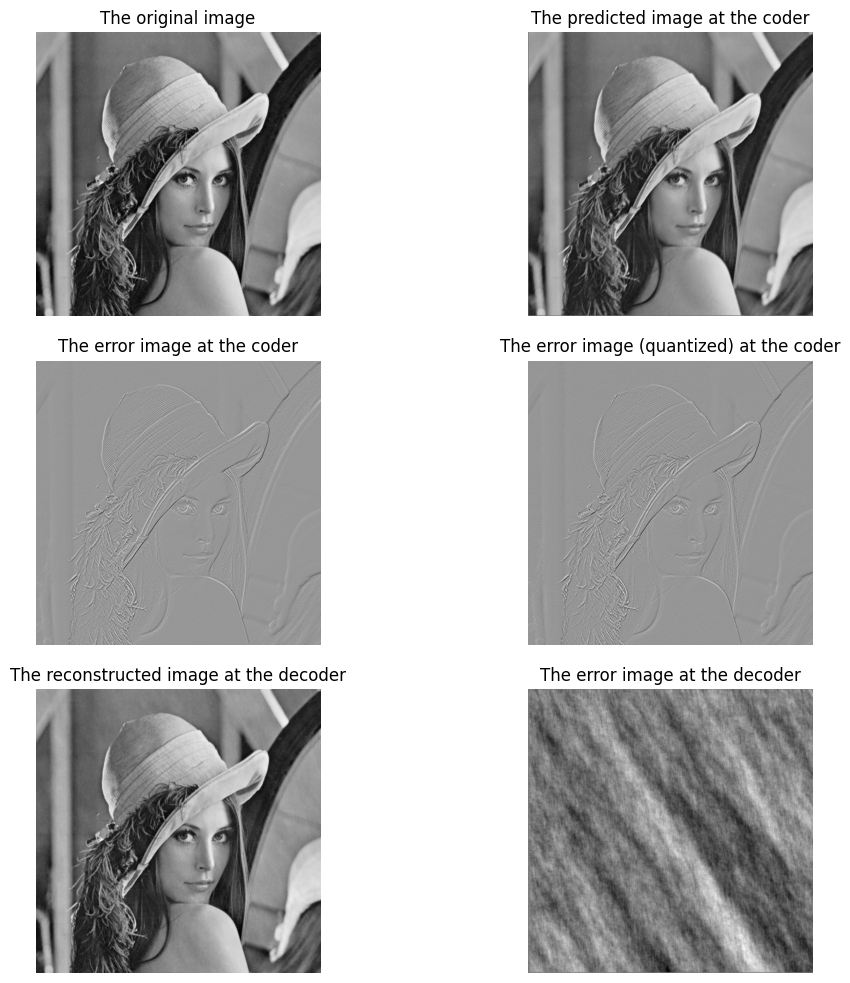

In [ ]:
# Display the results
fig, axs = plt.subplots(3, 2, figsize=(10,10))
fig.tight_layout()

axs[0,0].imshow(original_image, cmap='gray')
axs[0,0].set_title('The original image')
axs[0,0].set_axis_off()
axs[0,1].imshow(predicted_image, cmap='gray')
axs[0,1].set_title('The predicted image at the coder')
axs[0,1].set_axis_off()
axs[1,0].imshow(error_image, cmap='gray')
axs[1,0].set_title('The error image at the coder')
axs[1,0].set_axis_off()
axs[1,1].imshow(error_image_quantized, cmap='gray')
axs[1,1].set_title('The error image (quantized) at the coder')
axs[1,1].set_axis_off()
axs[2,0].imshow(reconstructed_image_quantized, cmap='gray')
axs[2,0].set_title('The reconstructed image at the decoder')
axs[2,0].set_axis_off()
axs[2,1].imshow(original_image - reconstructed_image_quantized, cmap='gray')
axs[2,1].set_title('The error image at the decoder')
axs[2,1].set_axis_off()

fig.show()

In [ ]:
# Performance analysis of DPCM
sigma_x = original_image.var() # full image
sigma_e = error_image.var() # segmented image
bit_reduction = 0.5 * np.log2(sigma_x/sigma_e) # R_PCM - R_DPCM (the bit reduction of DPCM over PCM at the same distortion)

print("The variance of the original image is %.4f" % sigma_x)
print("The variance of the error image before quantization is %.4f" % sigma_e)
print("At the same distortion, the bit reduction of DPCM over PCM is %.4f bits/pixel \n" % bit_reduction)

sigma_q_DPCM = quantization_error_DPCM.var()
R_DPCM = 0.5 * np.log2(sigma_e/sigma_q_DPCM)

print("The variance of the quantization error at the coder is %.4f" % sigma_q_DPCM)
print("At the %d-bit uniform quantization, the rate distortion function for DPCM is %.4f bits/pixel \n" % (B, R_DPCM))

# Compute SNR
noise = original_image - reconstructed_image_quantized
original_variance = original_image.var()
error_variance = noise.var()

SNR = 10*np.log10(original_variance/error_variance)
print("At the %d-bit uniform quantization, the SNR of the reconstructed image is %.4f dB" % (B, SNR))

The variance of the original image is 1.0000
The variance of the error image before quantization is 0.0188
At the same distortion, the bit reduction of DPCM over PCM is 2.8657 bits/pixel 

The variance of the quantization error at the coder is 0.0002
At the 6-bit uniform quantization, the rate distortion function for DPCM is 3.2860 bits/pixel 

At the 6-bit uniform quantization, the SNR of the reconstructed image is 21.4429 dB


In [ ]:
### Create the results for a set of bits for uniform quantization
folder_name = 'Predictive_Encoding'
B_min = 2 # Minimum bit for uniform quantization
B_max = 8 # Maximum bit for uniform quantization

# Create a folder in Colab for saving the images
file_location = '/content/' + folder_name
if not os.path.exists(file_location):
  os.mkdir(file_location)

file_name = 'The original_image.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.imsave(file_location + image + file_name, original_image, cmap='gray')

# The best linear prediction of the original image x(m,n)
# [x^(m,n) = a10*x(m-1,n) + a_11*x(m+1,n-1) + a01*x(m,n-1) + a11*x(m-1,n-1)]
predicted_image = np.zeros([M,N])

for m in range(1, M-1):
  for n in range(1, N):
    predicted_image[m,n] = a10*original_image[m-1,n] + a_11*original_image[m+1,n-1] + a01*original_image[m,n-1] + a11*original_image[m-1,n-1]

error_image = original_image[1:M-1,1:N] - predicted_image[1:M-1,1:N]

file_name = 'The predicted image at the coder.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.imsave(file_location + image + file_name, predicted_image[1:M-1,1:N], cmap='gray')

file_name = 'The error image without quantization at the coder.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.imsave(file_location + image + file_name, error_image, cmap='gray')

# Quantize the error image
Bs = range(B_min, B_max+1)
SNRs = np.zeros(len(Bs))
R_DPCMs = np.zeros(len(Bs))

for b in Bs:

  B = b; # # of bits for quantization
  quantization_level = 2 ** B;

  # Quantize the error image (segmented)
  quantization_step = (error_image.max() - error_image.min()) / (quantization_level - 1)
  error_image_quantized = np.round(error_image/quantization_step)
  error_image_quantized = error_image_quantized * quantization_step

  quantization_error_DPCM = error_image - error_image_quantized # q(m,n) = e(m,n) - e_0(m,n)

  file_name = '(' + str(B) + '-bit) The error image after ' + str(B) + '-bit uniform quantization at the coder.png'
  with open(file_location + image + file_name, 'wb') as f:
      plt.imsave(file_location + image + file_name, error_image_quantized, cmap='gray')

  # Reconstruct the original image x(m,n)
  # [x^(m,n) = a10*x(m-1,n) + a_11*x(m+1,n-1) + a01*x(m,n-1) + a11*x(m-1,n-1)]
  initial_condition = original_image.copy()
  initial_condition[1:M-1,1:N] = error_image_quantized
  reconstructed_image_quantized = initial_condition.copy()
  predicted_image_reconstructed_quantized = np.zeros([M,N])

  for n in range(1, N):
    for m in range(1, M-1):
      predicted_value = a10*reconstructed_image_quantized[m-1,n] + a_11*reconstructed_image_quantized[m+1,n-1] + a01*reconstructed_image_quantized[m,n-1] + a11*reconstructed_image_quantized[m-1,n-1]
      predicted_image_reconstructed_quantized[m,n] = predicted_value
      reconstructed_image_quantized[m,n] = predicted_value + reconstructed_image_quantized[m,n]

  # Compute SNR
  noise = original_image - reconstructed_image_quantized
  original_variance = original_image.var()
  error_variance = noise.var()

  SNR = 10*np.log10(original_variance/error_variance)
  SNR = SNR.round(4)
  SNRs[b-B_min] = SNR

  # Performance analysis of DPCM
  sigma_x = original_image.var() # full image
  sigma_e = error_image.var() # segmented image
  bit_reduction = 0.5 * np.log2(sigma_x/sigma_e) # R_PCM - R_DPCM (the bit reduction of DPCM over PCM at the same distortion)
  bit_reduction = bit_reduction.round(4)

  sigma_q_DPCM = quantization_error_DPCM.var()
  R_DPCM = 0.5 * np.log2(sigma_e/sigma_q_DPCM)
  R_DPCM = R_DPCM.round(4)
  R_DPCMs[b-B_min] = R_DPCM

  file_name = '(' + str(B) + '-bit) The reconstructed image at the decoder (assume Huffman encoding) - SNR ' + str(SNR) + ' dB - R_DPCM ' + str(R_DPCM) + ' bpp - ' + str(bit_reduction) + ' bit reduction.png'
  with open(file_location + image + file_name, 'wb') as f:
      plt.imsave(file_location + image + file_name, reconstructed_image_quantized, cmap='gray')

  file_name = '(' + str(B) + '-bit) The error image at the decoder - SNR ' + str(SNR) + ' dB - R_DPCM ' + str(R_DPCM) + ' bpp - ' + str(bit_reduction) + ' bit reduction.png'
  with open(file_location + image + file_name, 'wb') as f:
      plt.imsave(file_location + image + file_name, original_image - reconstructed_image_quantized, cmap='gray')

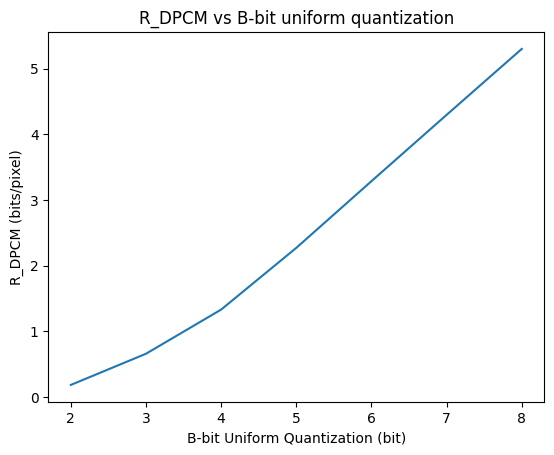

In [ ]:
plt.plot(Bs, R_DPCMs)
plt.xlabel('B-bit Uniform Quantization (bit)')
plt.ylabel('R_DPCM (bits/pixel)')
plt.title('R_DPCM vs B-bit uniform quantization')

file_name = 'R_DPCM vs B-bit Uniform Quantization.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.savefig(file_location + image + file_name)

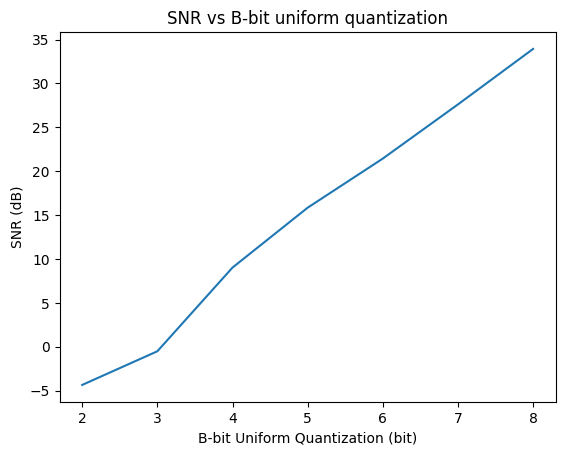

In [ ]:
plt.plot(Bs, SNRs)
plt.xlabel('B-bit Uniform Quantization (bit)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs B-bit uniform quantization')

file_name = 'SNR vs B-bit Uniform Quantization.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.savefig(file_location + image + file_name)

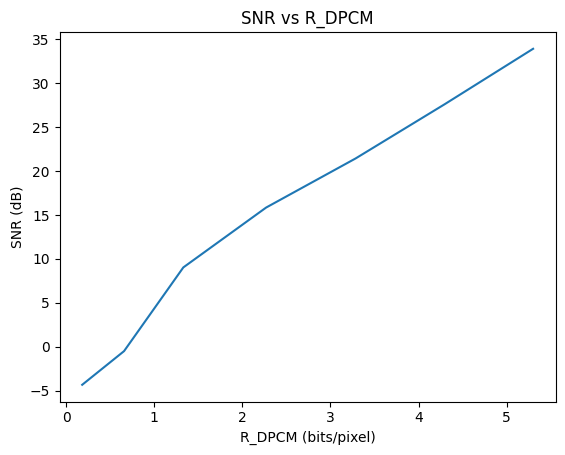

In [ ]:
plt.plot(R_DPCMs, SNRs)
plt.xlabel('R_DPCM (bits/pixel)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs R_DPCM')

file_name = 'SNR vs R_DPCM.png'
with open(file_location + image + file_name, 'wb') as f:
    plt.savefig(file_location + image + file_name)

In [ ]:
# Create a zip file from the folder to download (download all images at once)
zip_file_name = folder_name + ".zip"
location_to_zip = folder_name + "/"
!zip -r {zip_file_name} {location_to_zip}

# Download the zip file to your local computer
files.download(zip_file_name)

  adding: Predictive_Encoding/ (stored 0%)
  adding: Predictive_Encoding/Lena - (2-bit) The error image after 2-bit uniform quantization at the coder.png (deflated 3%)
  adding: Predictive_Encoding/Lena - (5-bit) The error image after 5-bit uniform quantization at the coder.png (deflated 1%)
  adding: Predictive_Encoding/Lena - (3-bit) The error image at the decoder - SNR -0.5114 dB - R_DPCM 0.6563 bpp - 2.8657 bit reduction.png (deflated 1%)
  adding: Predictive_Encoding/Lena - The error image without quantization at the coder.png (deflated 3%)
  adding: Predictive_Encoding/Lena - (2-bit) The error image at the decoder - SNR -4.3449 dB - R_DPCM 0.1811 bpp - 2.8657 bit reduction.png (deflated 0%)
  adding: Predictive_Encoding/Lena - (6-bit) The reconstructed image at the decoder (assume Huffman encoding) - SNR 21.4429 dB - R_DPCM 3.286 bpp - 2.8657 bit reduction.png (deflated 2%)
  adding: Predictive_Encoding/Lena - (3-bit) The error image after 3-bit uniform quantization at the coder.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>